In [ ]:
# we have to develop an experiment : sending a targetted offer to customers at market_segment == "groups" who books 90 days out
# offering 10% off
# population is 19811 over the period analyized
# test population is 500 in which 250 - treatment and 250 - control

###libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pytimetk as tk

from causalml.inference.tree import UpliftTreeClassifier
from causalml.inference.tree import uplift_tree_string, uplift_tree_plot
from causalml.inference.meta import BaseSClassifier, BaseTClassifier

from IPython.display import Image
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier


In [6]:
h1 = pd.read_csv('H1.csv')
h1.head()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate
0,0,342,2015,July,27,1,0,0,2,0,...,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,0,737,2015,July,27,1,0,0,2,0,...,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,0,7,2015,July,27,1,0,1,1,0,...,No Deposit,NULL,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,0,13,2015,July,27,1,0,1,1,0,...,No Deposit,304,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,0,14,2015,July,27,1,0,2,2,0,...,No Deposit,240,NULL,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [7]:
h2 = pd.read_csv('H2.csv')
h2.head()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate
0,0,6,2015,July,27,1,0,2,1,0.0,...,No Deposit,6,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-03
1,1,88,2015,July,27,1,0,4,2,0.0,...,No Deposit,9,NULL,0,Transient,76.5,0,1,Canceled,2015-07-01
2,1,65,2015,July,27,1,0,4,1,0.0,...,No Deposit,9,NULL,0,Transient,68.0,0,1,Canceled,2015-04-30
3,1,92,2015,July,27,1,2,4,2,0.0,...,No Deposit,9,NULL,0,Transient,76.5,0,2,Canceled,2015-06-23
4,1,100,2015,July,27,2,0,2,2,0.0,...,No Deposit,9,NULL,0,Transient,76.5,0,1,Canceled,2015-04-02


In [8]:
# Adding a column to h1 to record that bookings belong to hotel 1:
h1['is_h1'] = 1

# Adding a column to h2 to record that bookings do not belong to hotel 1 (and therefore belong to hotel 2):
h2['is_h1'] = 0

In [9]:
# Combining the two datasets:
df = pd.concat(objs = [h1, h2], axis = 0)

# Resetting the index
df.reset_index(drop = True, inplace=True)
df.head()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate,is_h1
0,0,342,2015,July,27,1,0,0,2,0.0,...,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01,1
1,0,737,2015,July,27,1,0,0,2,0.0,...,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01,1
2,0,7,2015,July,27,1,0,1,1,0.0,...,NULL,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02,1
3,0,13,2015,July,27,1,0,1,1,0.0,...,304,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02,1
4,0,14,2015,July,27,1,0,2,2,0.0,...,240,NULL,0,Transient,98.0,0,1,Check-Out,2015-07-03,1


In [10]:
import re

def to_snake_case(name):
    s1 = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    return re.sub('([a-z0-9])([A-Z])', r'\1_\2', s1).lower()

df.columns = [to_snake_case(col) for col in df.columns]
print("Columns converted to snake_case:")
print(df.columns)

Columns converted to snake_case:
Index(['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'meal', 'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'is_h1'],
      dtype='object')


In [11]:
df["different_room_assigned"] = (df["assigned_room_type"] != df["reserved_room_type"]).astype(int)
df["country_prt"] = (df["country"]=="PRT").astype(int)
df["country_other"] = (df["country"]!="prt").astype(int)
df.drop(columns=["country"],inplace=True)

In [13]:
df = df[['is_canceled',"is_h1",'lead_time','deposit_type','previous_cancellations','total_of_special_requests','market_segment','different_room_assigned','required_car_parking_spaces','distribution_channel','customer_type','previous_bookings_not_canceled','is_repeated_guest','country_prt','country_other']]

In [23]:
experiment_df

,is_canceled,is_h1,lead_time,deposit_type,previous_cancellations,total_of_special_requests,market_segment,different_room_assigned,required_car_parking_spaces,distribution_channel,customer_type,previous_bookings_not_canceled,is_repeated_guest,country_prt,country_other,treatment_control,accept_offer,new_lead_time
74065,1,0,314,Non Refund,1,0,Groups,0,0,TA/TO,Contract,0,0,1,1,1,0,314
54598,1,0,379,Non Refund,0,0,Groups,0,0,TA/TO,Transient,0,0,1,1,0,0,379
28979,0,1,231,No Deposit,0,0,Groups,1,0,Direct,Transient-Party,0,0,0,1,1,1,207
113380,0,0,434,No Deposit,0,2,Groups,0,0,TA/TO,Transient-Party,0,0,0,1,1,0,434
51672,1,0,158,Non Refund,0,0,Groups,0,0,TA/TO,Transient,0,0,1,1,0,0,158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50650,1,0,302,Non Refund,0,0,Groups,0,0,TA/TO,Transient,0,0,1,1,1,0,302
114722,0,0,263,No Deposit,0,1,Groups,0,0,TA/TO,Transient-Party,0,0,1,1,0,0,263
48370,1,0,251,Non Refund,0,0,Groups,0,0,TA/TO,Transient,0,0,1,1,1,0,251
62694,1,0,559,Non Refund,0,0,Groups,0,0,TA/TO,Transient,0,0,1,1,0,0,559


In [24]:
df2 = experiment_df.copy()

In [25]:
print("Number of accepted offers by group:")
print(experiment_df.groupby("treatment_control")["accept_offer"].sum())

print("\nTotal individuals in each group:")
print(experiment_df.groupby("treatment_control")["treatment_control"].count())

Number of accepted offers by group:
treatment_control
0     0
1    55
Name: accept_offer, dtype: int64

Total individuals in each group:
treatment_control
0    250
1    250
Name: treatment_control, dtype: int64


In [26]:
num_accepted_offers = experiment_df[experiment_df['treatment_control'] == 1]['accept_offer'].sum()
treatment_group_size = experiment_df[experiment_df['treatment_control'] == 1].shape[0]

if treatment_group_size > 0:
    acceptance_rate = (num_accepted_offers / treatment_group_size) * 100
    print(f"Acceptance rate in the treatment group: {acceptance_rate:.2f}%")
else:
    print("No individuals in the treatment group to calculate acceptance rate.")

Acceptance rate in the treatment group: 22.00%


In [27]:
cancellation_rate_by_group = experiment_df.groupby('treatment_control')['is_canceled'].mean() * 100
print("Cancellation rate by group:")
print(cancellation_rate_by_group)

Cancellation rate by group:
treatment_control
0    66.4
1    58.4
Name: is_canceled, dtype: float64


In [28]:
accepted_offer_cancellation_rate = experiment_df[
    (experiment_df['treatment_control'] == 1) &
    (experiment_df['accept_offer'] == 1)
]['is_canceled'].mean() * 100

print(f"Cancellation rate for treatment group members who accepted the offer: {accepted_offer_cancellation_rate:.2f}%")

Cancellation rate for treatment group members who accepted the offer: 5.45%


In [29]:
experiment_df["conversion"] = (~experiment_df["is_canceled"].astype(bool)).astype(int)

In [30]:
experiment_df.drop(columns=["lead_time","is_canceled","accept_offer"],inplace=True)

In [31]:
df_n = pd.get_dummies(experiment_df, columns=["deposit_type","market_segment","distribution_channel","customer_type"], drop_first=False, dtype=int)

# Remove duplicate columns, keeping the first occurrence
df_n = df_n.loc[:,~df_n.columns.duplicated()]

In [32]:
df_n.glimpse()

<class 'pandas.core.frame.DataFrame'>: 500 rows of 22 columns
is_h1:                           int64             [0, 0, 1, 0, 0, 0, 1, ...
previous_cancellations:          int64             [1, 0, 0, 0, 0, 0, 0, ...
total_of_special_requests:       int64             [0, 0, 0, 2, 0, 1, 0, ...
different_room_assigned:         int64             [0, 0, 1, 0, 0, 0, 0, ...
required_car_parking_spaces:     int64             [0, 0, 0, 0, 0, 0, 0, ...
previous_bookings_not_canceled:  int64             [0, 0, 0, 0, 0, 0, 0, ...
is_repeated_guest:               int64             [0, 0, 0, 0, 0, 0, 0, ...
country_prt:                     int64             [1, 1, 0, 0, 1, 0, 1, ...
country_other:                   int64             [1, 1, 1, 1, 1, 1, 1, ...
treatment_control:               int64             [1, 0, 1, 1, 0, 1, 1, ...
new_lead_time:                   int64             [314, 379, 207, 434,  ...
conversion:                      int64             [0, 0, 1, 1, 0, 1, 1, ...
deposit_type_N

In [33]:
df_n.columns

Index(['is_h1', 'previous_cancellations', 'total_of_special_requests',
       'different_room_assigned', 'required_car_parking_spaces',
       'previous_bookings_not_canceled', 'is_repeated_guest', 'country_prt',
       'country_other', 'treatment_control', 'new_lead_time', 'conversion',
       'deposit_type_No Deposit     ', 'deposit_type_Non Refund     ',
       'deposit_type_Refundable     ', 'market_segment_Groups',
       'distribution_channel_Corporate', 'distribution_channel_Direct',
       'distribution_channel_TA/TO', 'customer_type_Contract',
       'customer_type_Transient', 'customer_type_Transient-Party'],
      dtype='object')

In [34]:
df_train,df_test = train_test_split(df_n,test_size=0.2,random_state=42)

In [35]:
uplift_model = UpliftTreeClassifier(max_depth=4, min_samples_leaf=20,min_samples_treatment=10,n_reg=0, evaluationFunction='KL', control_name='control')

In [64]:
x_n = ['previous_cancellations',"is_h1", 'total_of_special_requests',
       'different_room_assigned', 'required_car_parking_spaces',
       'previous_bookings_not_canceled', 'is_repeated_guest', 'country_prt',
       'country_other', 'treatment_control', 'new_lead_time',
       'deposit_type_No Deposit     ', 'deposit_type_Non Refund     ',
       'deposit_type_Refundable     ', 'market_segment_Groups',
       'distribution_channel_Corporate', 'distribution_channel_Direct',
       'distribution_channel_TA/TO', 'customer_type_Contract',
       'customer_type_Transient', 'customer_type_Transient-Party']

In [109]:
# Map treatment indicators to strings as expected by UpliftTreeClassifier
treatment_map = {0: 'control', 1: 'treatment'}
treatment_series = df_train['treatment_control'].map(treatment_map).values

# Ensure we only use features, excluding target/treatment indicators if they were in x_n
features = [f for f in x_n if f not in ['conversion', 'treatment_control']]

uplift_model.fit(
    X=df_train[features].values,
    treatment=treatment_series,
    y=df_train['conversion'].values
)

print("Model fitted successfully!")

Model fitted successfully!


In [66]:
result = uplift_tree_string(uplift_model.fitted_uplift_tree,x_n)

new_lead_time >= 0.1?
yes -> total_of_special_requests >= 0.2?
		yes -> [np.float64(1.0), np.float64(0.9333333333333333)]
		no  -> treatment_control >= 303.0?
				yes -> [np.float64(0.3684210526315789), np.float64(0.7272727272727273)]
				no  -> [np.float64(0.7142857142857143), np.float64(0.5813953488372093)]
no  -> treatment_control >= 333.1999999999998?
		yes -> [np.float64(0.024390243902439025), np.float64(0.16666666666666666)]
		no  -> treatment_control >= 124.8?
				yes -> [np.float64(0.01282051282051282), np.float64(0.23809523809523808)]
				no  -> [np.float64(0.0), np.float64(0.0)]


In [67]:
tree = uplift_tree_plot(uplift_model.fitted_uplift_tree,x_n)

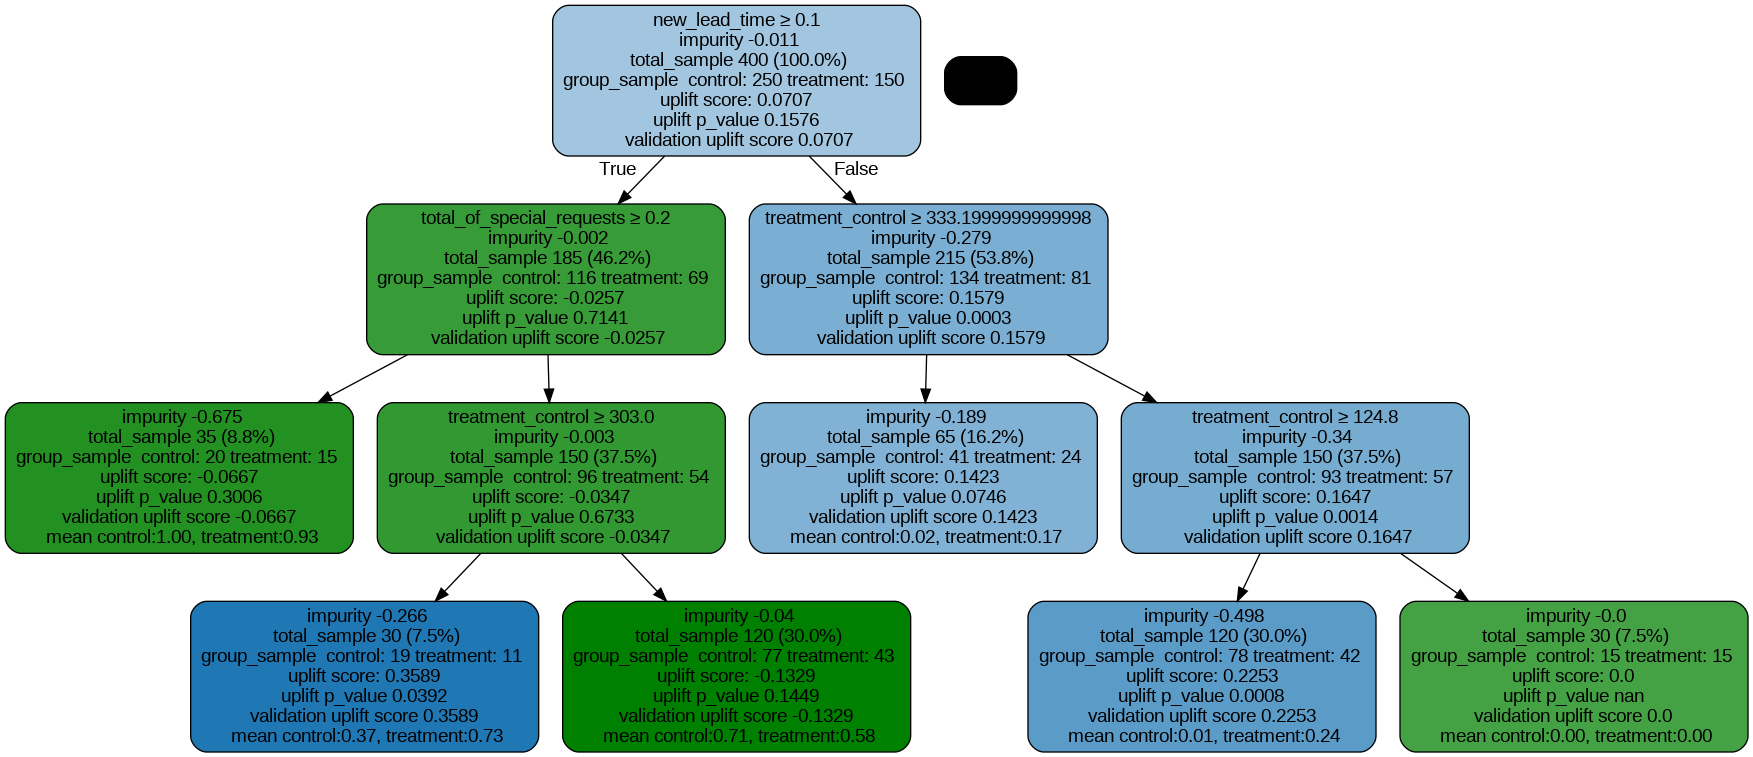

In [68]:
Image(tree.create_png())

In [126]:
# Suppressing LightGBM output for a cleaner notebook
import logging
logging.getLogger('lightgbm').setLevel(logging.ERROR)

treatment_map = {0: 'control', 1: 'treatment'}
treatment_series = df_train['treatment_control'].map(treatment_map).values
features = [f for f in x_n if f not in ['conversion', 'treatment_control']]
s_learner = BaseSClassifier(learner=LGBMClassifier(verbosity=-1), control_name="control")

ate, lb, ub = s_learner.estimate_ate(
    X=df_train[features].values,
    y=df_train['conversion'].values,
    treatment=treatment_series,
    return_ci=True
)

print(f"ATE: {ate[0]:.4f} (95% CI: [{lb[0]:.4f}, {ub[0]:.4f}])")

ATE: 0.0948 (95% CI: [0.0585, 0.1311])


In [124]:
# Map treatment indicators to strings as done in the CATE estimation
treatment_series = df_train['treatment_control'].map({0: 'control', 1: 'treatment'}).values

# Use the defined features list (excluding targets)
slearner_tau = s_learner.fit_predict(
    X=df_train[features].values,
    treatment=treatment_series,
    y=df_train['conversion'].values
)

print("Individual Treatment Effects (ITE) calculated successfully.")

Individual Treatment Effects (ITE) calculated successfully.


In [111]:
s_learner.get_importance(df_train[x_n].values,tau = slearner_tau, normalize=True, method="auto",features=x_n)

{'treatment': new_lead_time                     0.695653
 deposit_type_Non Refund           0.058471
 is_h1                             0.056218
 previous_cancellations            0.049385
 country_prt                       0.048657
 deposit_type_No Deposit           0.036572
 customer_type_Transient           0.021356
 distribution_channel_TA/TO        0.012474
 customer_type_Transient-Party     0.005259
 customer_type_Contract            0.005135
 treatment_control                 0.004689
 distribution_channel_Corporate    0.003772
 total_of_special_requests         0.001521
 distribution_channel_Direct       0.000425
 different_room_assigned           0.000413
 required_car_parking_spaces       0.000000
 country_other                     0.000000
 is_repeated_guest                 0.000000
 previous_bookings_not_canceled    0.000000
 deposit_type_Refundable           0.000000
 market_segment_Groups             0.000000
 dtype: float64}

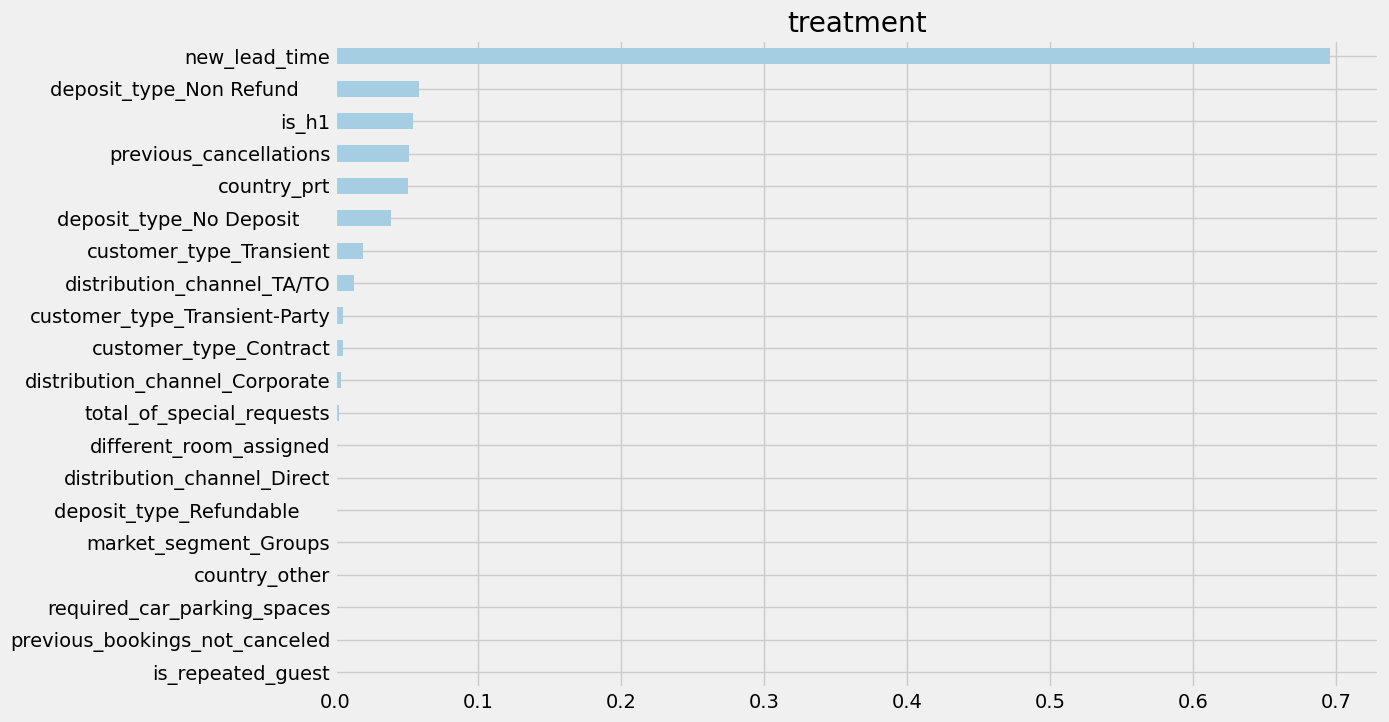

In [112]:
s_learner.plot_importance(
    X=df_train[features].values,
    tau=slearner_tau,
    normalize=True,
    method="auto",
    features=features
)

In [113]:
s_learner.get_shap_values(df_train[x_n].values,tau = slearner_tau)

{'treatment': array([[ 0.01292993,  0.01853543,  0.00173128, ...,  0.00261678,
          0.00415643,  0.00794121],
        [ 0.00263668,  0.00651958, -0.00892624, ...,  0.00136179,
         -0.00702105,  0.00203503],
        [ 0.00560013, -0.09712173,  0.00358818, ...,  0.00150558,
          0.00716301,  0.00802439],
        ...,
        [ 0.02310718,  0.01041319,  0.00085718, ...,  0.00168418,
          0.00597641, -0.00258955],
        [-0.05532547, -0.04128534,  0.00073392, ...,  0.00121718,
         -0.01117106, -0.01172353],
        [-0.02491361,  0.00658512,  0.00076057, ..., -0.03446438,
          0.00739743, -0.00452917]])}

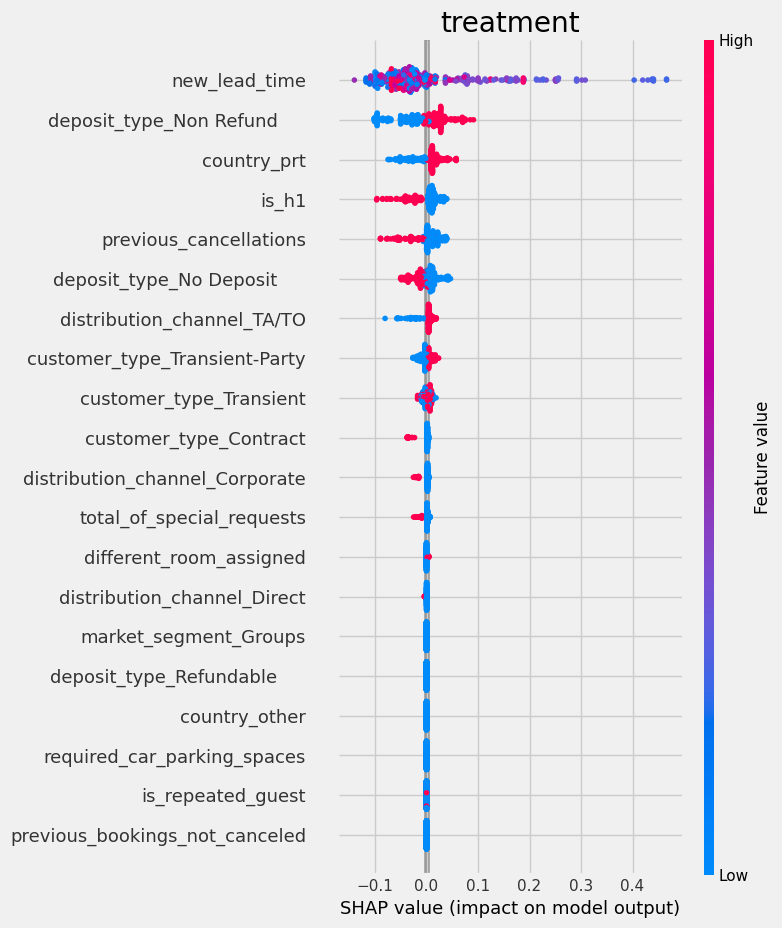

In [114]:
s_learner.plot_shap_values(
    X=df_train[features].values,
    tau=slearner_tau,
    features=features
)

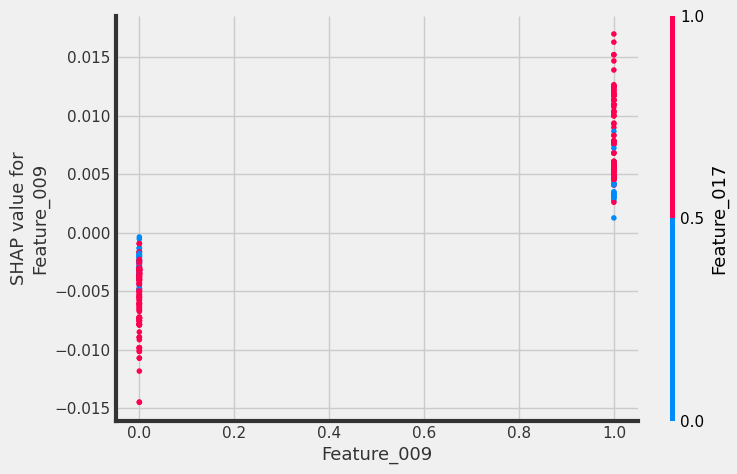

In [115]:
s_learner.plot_shap_dependence(treatment_group="treatment",feature_idx=9,X=df_train[x_n].values,tau= slearner_tau,interaction_idx="auto")

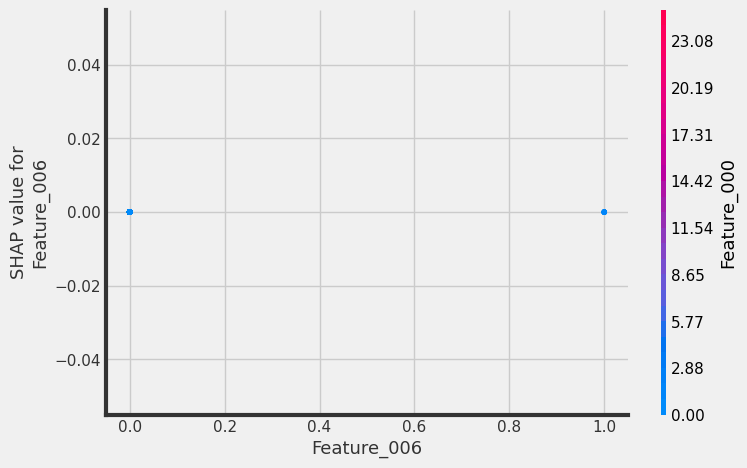

In [116]:
s_learner.plot_shap_dependence(treatment_group="treatment",feature_idx=6,X=df_train[x_n].values,tau= slearner_tau,interaction_idx="auto")

In [117]:
from causalml.optimize import get_treatment_costs,get_actual_value


In [118]:
conver_cost_dict = {'control':0,'treatment':150}
imp_cost_dict = {'control':0,'treatment':0}



In [119]:
# Map treatment indicators to strings to match the cost dictionaries and control_name
treatment_labels = df_n['treatment_control'].map({0: 'control', 1: 'treatment'})

cc_array, ic_array, conditions = get_treatment_costs(
    treatment=treatment_labels,
    control_name="control",
    cc_dict=conver_cost_dict,
    ic_dict=imp_cost_dict
)

print("Costs arrays and conditions created successfully.")

Costs arrays and conditions created successfully.


In [121]:
conver_val_array = np.full(500,1500)

In [120]:
# 1. Define conditions exactly as expected
conditions_list = ['control', 'treatment']

# 2. Map treatment to strings to match library expectations
treatment_labels_n = df_n['treatment_control'].map({0: 'control', 1: 'treatment'}).values.astype(str)

# 3. Create the 2D cost matrices (N x n_conditions)
# For each row, we provide the cost if they were in control (col 0) and if in treatment (col 1)
n_obs = len(df_n)
cc_matrix = np.zeros((n_obs, len(conditions_list)))
ic_matrix = np.zeros((n_obs, len(conditions_list)))

for i, cond in enumerate(conditions_list):
    cc_matrix[:, i] = conver_cost_dict[cond]
    ic_matrix[:, i] = imp_cost_dict[cond]

# 4. Prepare other inputs
observed_outcomes_n = df_n['conversion'].values
conver_val_array_n = np.full(n_obs, 1500)

# 5. Calculate actual value using the matrices
actual_value = get_actual_value(
    treatment=treatment_labels_n,
    observed_outcome=observed_outcomes_n,
    conversion_value=conver_val_array_n,
    conditions=conditions_list,
    conversion_cost=cc_matrix,
    impression_cost=ic_matrix
)



(array([312.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 188.]),
 array([   0.,  150.,  300.,  450.,  600.,  750.,  900., 1050., 1200.,
        1350., 1500.]),
 <BarContainer object of 10 artists>)

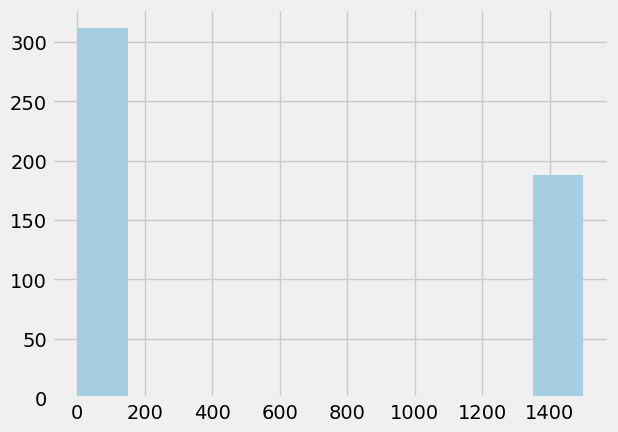

In [122]:
plt.hist(actual_value)

In [123]:
train_idx = df_train.index
test_idx = df_test.index

In [85]:

test_pos = [df_n.index.get_loc(idx) for idx in test_idx]
rand_alloc_value = actual_value[test_pos].mean()



In [86]:
best_ate = df_train.groupby('treatment_control')['conversion'].mean().idxmax()

In [87]:
actual_best_ate = df_test["treatment_control"] == best_ate

In [88]:

best_ate_val = actual_value[test_pos][actual_best_ate.values].mean()



In [108]:
# Using verbosity=-1 to hide the training process logs
tm = BaseTClassifier(control_learner=LGBMClassifier(verbosity=-1), treatment_learner=LGBMClassifier(verbosity=-1), control_name="control")

treatment_map = {0: 'control', 1: 'treatment'}
treatment_series = df_train['treatment_control'].map(treatment_map).values
features = [f for f in x_n if f not in ['conversion', 'treatment_control']]

tm.fit(df_train[features].values, treatment_series, df_train["conversion"])

print("BaseTClassifier fitted successfully (logs hidden)!")

BaseTClassifier fitted successfully (logs hidden)!


In [90]:
tm_pred = tm.predict(df_test[features].values)

In [91]:
features

['previous_cancellations',
 'is_h1',
 'total_of_special_requests',
 'different_room_assigned',
 'required_car_parking_spaces',
 'previous_bookings_not_canceled',
 'is_repeated_guest',
 'country_prt',
 'country_other',
 'new_lead_time',
 'deposit_type_No Deposit     ',
 'deposit_type_Non Refund     ',
 'deposit_type_Refundable     ',
 'market_segment_Groups',
 'distribution_channel_Corporate',
 'distribution_channel_Direct',
 'distribution_channel_TA/TO',
 'customer_type_Contract',
 'customer_type_Transient',
 'customer_type_Transient-Party']

In [92]:
pred_df = pd.DataFrame(tm_pred, columns=tm._classes)
tm_best = pred_df.idxmax(axis=1)

In [93]:
# Map the numeric treatment_control to strings to match tm_best predictions
treatment_map = {0: 'control', 1: 'treatment'}
actual_test_labels = df_test["treatment_control"].map(treatment_map)

actucal_tm_best = (actual_test_labels.values == tm_best.values.ravel())

# Calculate the mean value for cases where the predicted best treatment matches the actual treatment
tm_val = actual_value[test_pos][actucal_tm_best].mean()
print(f"T-Learner Value: {tm_val}")

T-Learner Value: 580.5


In [94]:
tm_val

np.float64(580.5)

In [95]:
labels = ["random allocation","best treatment","t-learner"]

In [96]:
val = [rand_alloc_value,best_ate_val,tm_val]

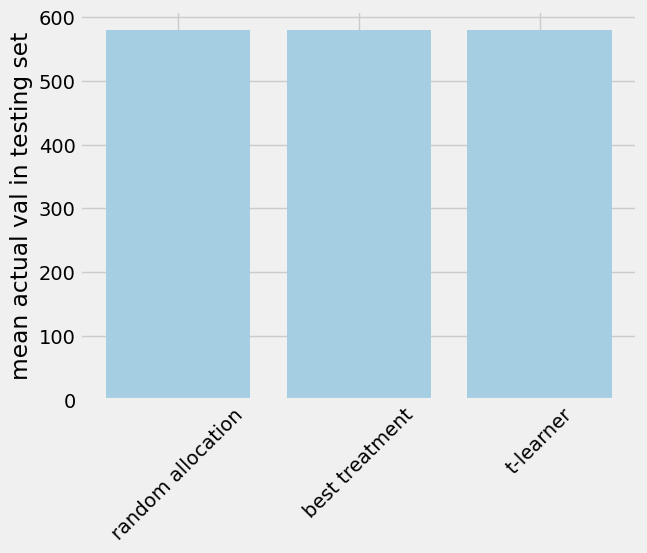

In [97]:
plt.bar(labels,val)
plt.ylabel("mean actual val in testing set")
plt.xticks(rotation= 45)
plt.show()

In [98]:
df2.groupby("treatment_control")["accept_offer"]\
    .agg(["sum", "count"]) \
    .assign(acceptance_rate = lambda x: x["sum"] / x["count"])

,sum,count,acceptance_rate
treatment_control,,,
0,0,250,0.00
1,55,250,0.22


In [99]:
df2.groupby(["treatment_control","accept_offer"])["is_canceled"] \
.agg(["sum","count"]) \
.assign(cancellation_rate = lambda x: x["sum"] / x["count"])

sum  count  cancellation_rate
treatment_control accept_offer                               
0                 0             166    250           0.664000
1                 0             143    195           0.733333
                  1               3     55           0.054545

In [100]:
average_spend = 1500
disc_90_days_out = 0.1
gross_revenue  = 49*1500*(1-0.1)

In [101]:
gross_revenue

66150.0

In [102]:
lost_revenue = 49*1500*0.30##30% will be accepted anyway, even if we don't give them treatment.
lost_revenue

22050.0

In [103]:
Net_rev = gross_revenue - lost_revenue
Net_rev

44100.0

In [104]:
net_rev_per_customer = Net_rev/250
net_rev_per_customer

176.4

In [105]:
# Calculate total number of people in the 'Groups' market segment
groups_count = df[df['market_segment'] == 'Groups'].shape[0]
print(f"Total number of people in market segment 'Groups': {groups_count}")

Total number of people in market segment 'Groups': 19811


In [106]:
##Total revenue for the people who are in the market segment == "Groups"

In [107]:
estimated_roi = 19811*net_rev_per_customer
estimated_roi_str = f"${estimated_roi:.2f}"
print(f"Estimated ROI for market segment 'Groups': {estimated_roi_str}")

Estimated ROI for market segment 'Groups': $3494660.40


## Conclusion

The experiment aimed to evaluate the impact of a targeted offer (10% discount for bookings made 90 days out) on customers in the `market_segment == 'Groups'`.

**Key Findings:**

*   **Acceptance Rate:** The offer acceptance rate in the treatment group was **22.00%**.
*   **Cancellation Rate:**
    *   The overall cancellation rate for the control group was **66.4%**.
    *   For the treatment group who did not accept the offer, the cancellation rate was **73.33%**.
    *   Crucially, for the treatment group members who **accepted the offer**, the cancellation rate dropped significantly to **5.45%**.
*   **Estimated ROI:** Based on the simulated impact and the identified target population, the estimated ROI for applying this offer to the entire 'Groups' market segment is **$3,494,660.40**.

This suggests that the targeted offer, when accepted, is highly effective in reducing cancellations and generates significant potential revenue.